<a href="https://colab.research.google.com/github/DenisDrobyshev/universum/blob/master/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%964_%D0%9F%D0%BE%D1%81%D1%82%D1%80%D0%BE%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B3%D0%BB%D1%83%D0%B1%D0%BE%D0%BA%D0%BE%D0%B9_%D1%81%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D0%BE%D0%B9_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D0%BE%D0%B9_%D1%81%D0%B5%D1%82%D0%B8_%D0%B4%D0%BB%D1%8F_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B9%2C_%D1%81_%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5%D0%BC_BatchNormalization()_%D0%B8_Dropout()_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Построение сверточной нейронной сети для классификации изображений, с использованием BatchNormalization() и Dropout()**

## **Задание 1. Построение сверточной нейронной сети для классификации изображений из датасета CIFAR-100, с использованием BatchNormalization() и Dropout():**



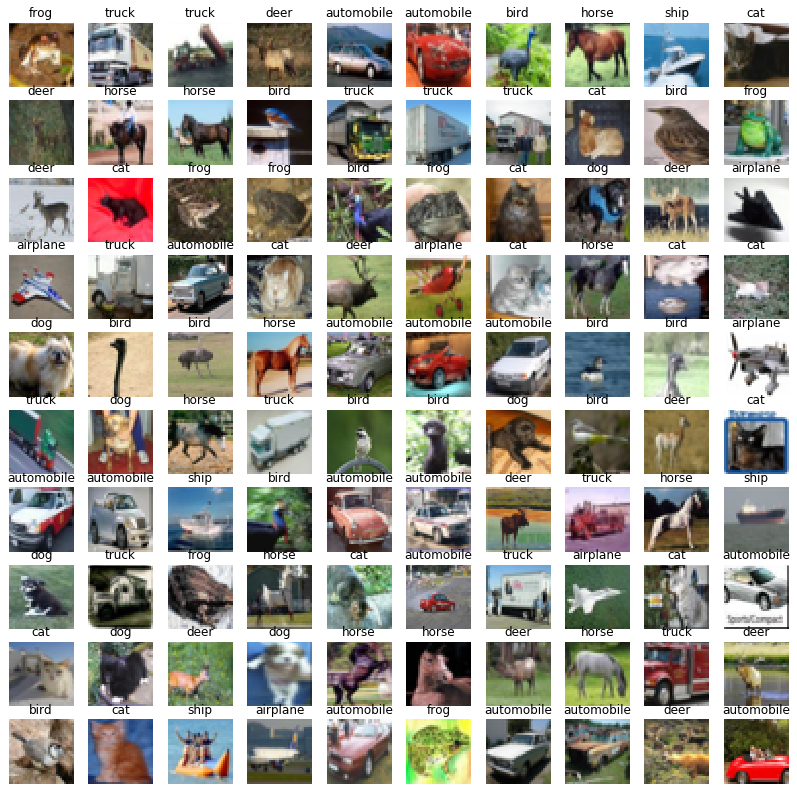

### **1.1. Загрузите исходный датасет. Разделите его на обучающую и тестовую выборки:**



*P.S.: Не забудьте обратить внимание на размерность (shape) исходных данных и при необходимости измените её (см. примеры из предыдущих занятий)*

[Информация о датасете](https://www.cs.toronto.edu/%7Ekriz/cifar.html)

[Техническая документация по использованию датасета в Keras](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/cifar100/load_data)





In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from keras.datasets import cifar100
from keras.models import Sequential, Model
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, Input
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger, TensorBoard
from keras.utils import to_categorical
import tensorflow as tf

os.makedirs('models/practical_work_4', exist_ok=True)
os.makedirs('logs/practical_work_4', exist_ok=True)

In [ ]:
(trainX, trainy), (testX, testy) = cifar100.load_data(label_mode='fine')

print('Train: X = ', trainX.shape)
print('Train: y = ', trainy.shape)
print('Test: X = ', testX.shape)
print('Test: y = ', testy.shape)

label_names = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

print(f'\nКоличество классов: {len(label_names)}')
print(f'Примеры классов: {label_names[:10]}')
print(f'Последние классы: {label_names[-10:]}')

Train: X =  (50000, 32, 32, 3)
Train: y =  (50000, 1)
Test: X =  (10000, 32, 32, 3)
Test: y =  (10000, 1)

Количество классов: 100
Примеры классов: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle']
Последние классы: ['train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']


### **1.2. Визуализируйте несколько изображений из датасета:**


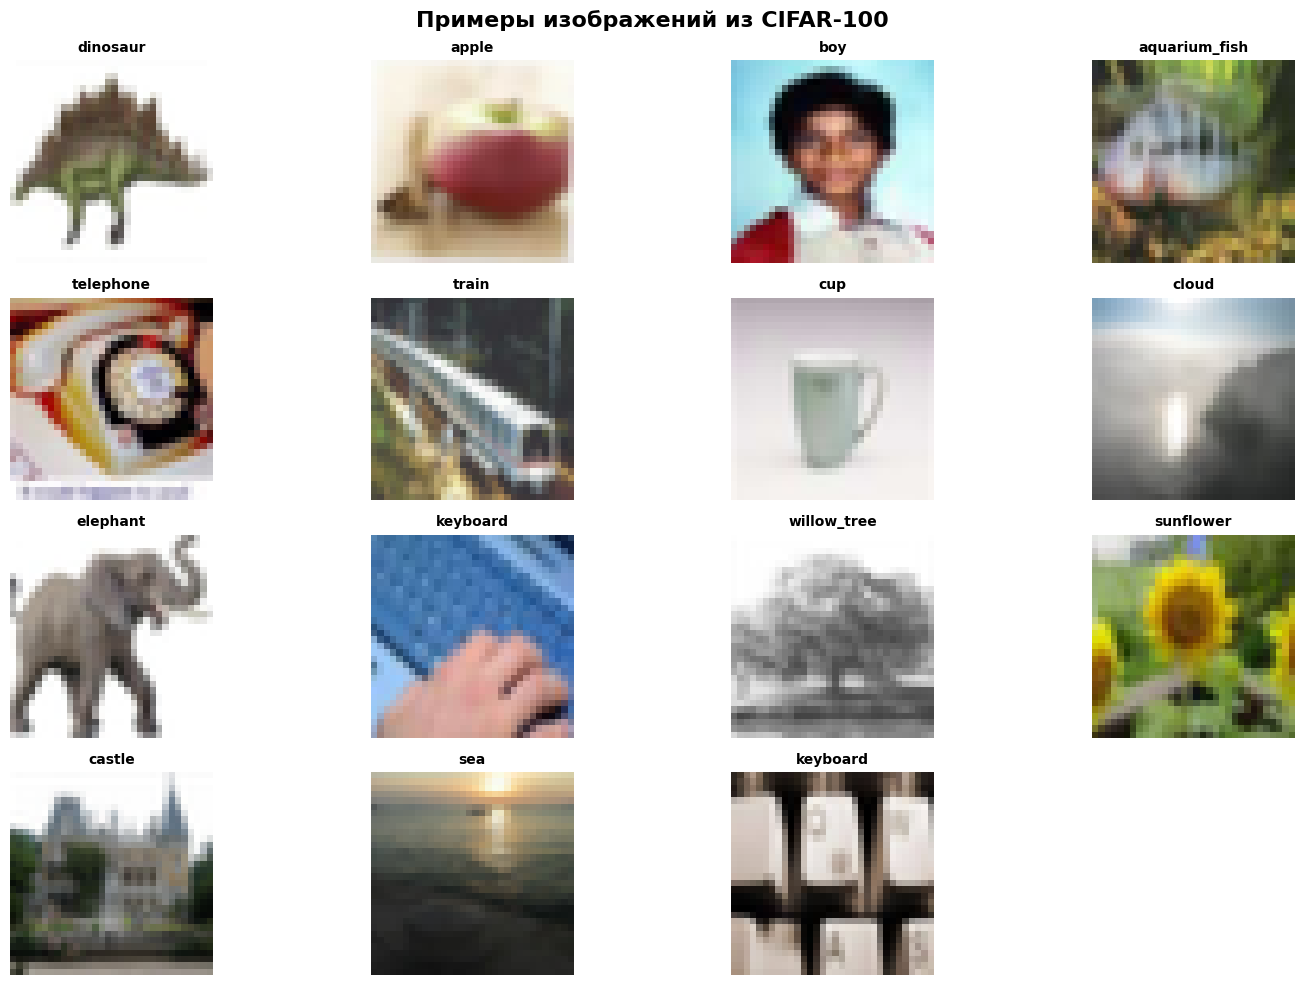

In [ ]:
plt.figure(figsize=(15, 10))

for i in range(1, 16):
    plt.subplot(4, 4, i)
    plt.imshow(trainX[i])
    plt.title(f'{label_names[trainy[i][0]]}', fontsize=10, fontweight='bold')
    plt.axis('off')

plt.suptitle('Примеры изображений из CIFAR-100', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **1.3. Произведите нормализацию данных:**

In [ ]:
trainX_norm = trainX.astype('float32') / 255.0
testX_norm = testX.astype('float32') / 255.0

# One-hot encoding для меток (100 классов)
trainy_cat = to_categorical(trainy, 100)
testy_cat = to_categorical(testy, 100)

print('Train X shape after normalization:', trainX_norm.shape)
print('Train y shape after one-hot encoding:', trainy_cat.shape)
print('Test X shape after normalization:', testX_norm.shape)
print('Test y shape after one-hot encoding:', testy_cat.shape)

Train X shape after normalization: (50000, 32, 32, 3)
Train y shape after one-hot encoding: (50000, 100)
Test X shape after normalization: (10000, 32, 32, 3)
Test y shape after one-hot encoding: (10000, 100)


### **1.4. Создайте модель сверточной нейронной сети для решения поставленной задачи без использования BatchNormalization() и Dropout():**

Имя данной модели: model_1

In [ ]:
def create_model_1():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(256, activation='relu'),
        Dense(100, activation='softmax')
    ])
    return model

model_1 = create_model_1()

model_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 837,252 (3.19 MB)

 Trainable params: 837,252 (3.19 MB)

 Non-trainable params: 0 (0.00 B)

Обучите созданную модель

In [ ]:
callbacks_1 = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='models/practical_work_4/model_1_best.h5',
                    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    CSVLogger('models/practical_work_4/model_1_history.csv', append=False),
    TensorBoard(log_dir='logs/practical_work_4/model_1', histogram_freq=1)
]

history_1 = model_1.fit(
    trainX_norm, trainy_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks_1,
    verbose=1
)

test_loss_1, test_acc_1 = model_1.evaluate(testX_norm, testy_cat, verbose=0)
print(f'\nModel_1 - Test Accuracy: {test_acc_1:.4f}, Test Loss: {test_loss_1:.4f}')

Epoch 1/50
619/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0419 - loss: 4.3011
Epoch 1: val_accuracy improved from None to 0.14400, saving model to models/practical_work_4/model_1_best.h5



Epoch 1: finished saving model to models/practical_work_4/model_1_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.0831 - loss: 4.0052 - val_accuracy: 0.1440 - val_loss: 3.5809 - learning_rate: 0.0010
Epoch 2/50
619/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1938 - loss: 3.3365
Epoch 2: val_accuracy improved from 0.14400 to 0.25230, saving model to models/practical_work_4/model_1_best.h5



Epoch 2: finished saving model to models/practical_work_4/model_1_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.2190 - loss: 3.2197 - val_accuracy: 0.2523 - val_loss: 3.0528 - learning_rate: 0.0010
Epoch 3/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3006 - loss: 2.7960
Epoch 3: val_accuracy improved from 0.25230 to 0.30850, saving model to models/practical_work_4/model_1_best.h5



Epoch 3: finished saving model to models/practical_work_4/model_1_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3124 - loss: 2.7467 - val_accuracy: 0.3085 - val_loss: 2.7687 - learning_rate: 0.0010
Epoch 4/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3790 - loss: 2.3949
Epoch 4: val_accuracy improved from 0.30850 to 0.34210, saving model to models/practical_work_4/model_1_best.h5



Epoch 4: finished saving model to models/practical_work_4/model_1_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3794 - loss: 2.3966 - val_accuracy: 0.3421 - val_loss: 2.6425 - learning_rate: 0.0010
Epoch 5/50
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4467 - loss: 2.0823
Epoch 5: val_accuracy improved from 0.34210 to 0.35580, saving model to models/practical_work_4/model_1_best.h5



Epoch 5: finished saving model to models/practical_work_4/model_1_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4426 - loss: 2.1112 - val_accuracy: 0.3558 - val_loss: 2.5824 - learning_rate: 0.0010
Epoch 6/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5095 - loss: 1.8010
Epoch 6: val_accuracy improved from 0.35580 to 0.36490, saving model to models/practical_work_4/model_1_best.h5



Epoch 6: finished saving model to models/practical_work_4/model_1_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4997 - loss: 1.8384 - val_accuracy: 0.3649 - val_loss: 2.6939 - learning_rate: 0.0010
Epoch 7/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5792 - loss: 1.5252
Epoch 7: val_accuracy did not improve from 0.36490
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5611 - loss: 1.5879 - val_accuracy: 0.3606 - val_loss: 2.7375 - learning_rate: 0.0010
Epoch 8/50
620/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6397 - loss: 1.2800
Epoch 8: val_accuracy improved from 0.36490 to 0.36700, saving model to models/practical_work_4/model_1_best.h5



Epoch 8: finished saving model to models/practical_work_4/model_1_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6191 - loss: 1.3463 - val_accuracy: 0.3670 - val_loss: 2.8511 - learning_rate: 0.0010
Epoch 9/50
620/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7034 - loss: 1.0290
Epoch 9: val_accuracy did not improve from 0.36700
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6815 - loss: 1.1077 - val_accuracy: 0.3571 - val_loss: 3.1294 - learning_rate: 0.0010
Epoch 10/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7604 - loss: 0.8156
Epoch 10: val_accuracy did not improve from 0.36700

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7358 - loss: 0.8974 - val_accuracy: 0.3493 - val_loss: 3.3932 - learning_rate: 0.0010
Epoch 11/50
619/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8615 - loss: 0.4596
Epoch 11: val_accuracy did not improve from 0.36700
625/625 

### **1.5. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием BatchNormalization():**

Имя данной модели: model_2

In [ ]:
def create_model_2():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(100, activation='softmax')
    ])
    return model

model_2 = create_model_2()

model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 840,068 (3.20 MB)

 Trainable params: 838,660 (3.20 MB)

 Non-trainable params: 1,408 (5.50 KB)

Обучите созданную модель

In [ ]:
callbacks_2 = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='models/practical_work_4/model_2_best.h5',
                    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    CSVLogger('models/practical_work_4/model_2_history.csv', append=False),
    TensorBoard(log_dir='logs/practical_work_4/model_2', histogram_freq=1)
]

history_2 = model_2.fit(
    trainX_norm, trainy_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks_2,
    verbose=1
)

test_loss_2, test_acc_2 = model_2.evaluate(testX_norm, testy_cat, verbose=0)
print(f'\nModel_2 - Test Accuracy: {test_acc_2:.4f}, Test Loss: {test_loss_2:.4f}')

Epoch 1/50
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0671 - loss: 4.5450
Epoch 1: val_accuracy improved from None to 0.11360, saving model to models/practical_work_4/model_2_best.h5



Epoch 1: finished saving model to models/practical_work_4/model_2_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.1020 - loss: 4.0981 - val_accuracy: 0.1136 - val_loss: 4.0087 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1965 - loss: 3.3586
Epoch 2: val_accuracy improved from 0.11360 to 0.28000, saving model to models/practical_work_4/model_2_best.h5



Epoch 2: finished saving model to models/practical_work_4/model_2_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.2156 - loss: 3.2537 - val_accuracy: 0.2800 - val_loss: 2.9099 - learning_rate: 0.0010
Epoch 3/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2838 - loss: 2.8728
Epoch 3: val_accuracy improved from 0.28000 to 0.34650, saving model to models/practical_work_4/model_2_best.h5



Epoch 3: finished saving model to models/practical_work_4/model_2_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.2933 - loss: 2.8059 - val_accuracy: 0.3465 - val_loss: 2.5411 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3444 - loss: 2.5437
Epoch 4: val_accuracy improved from 0.34650 to 0.36170, saving model to models/practical_work_4/model_2_best.h5



Epoch 4: finished saving model to models/practical_work_4/model_2_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.3485 - loss: 2.5264 - val_accuracy: 0.3617 - val_loss: 2.4573 - learning_rate: 0.0010
Epoch 5/50
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3889 - loss: 2.3245
Epoch 5: val_accuracy improved from 0.36170 to 0.43680, saving model to models/practical_work_4/model_2_best.h5


...


Epoch 29: finished saving model to models/practical_work_4/model_2_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7200 - loss: 0.9131 - val_accuracy: 0.5763 - val_loss: 1.6786 - learning_rate: 5.0000e-04
Epoch 30/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7354 - loss: 0.8731
Epoch 30: val_accuracy improved from 0.57630 to 0.57710, saving model to models/practical_work_4/model_2_best.h5



Epoch 30: finished saving model to models/practical_work_4/model_2_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7272 - loss: 0.8920 - val_accuracy: 0.5771 - val_loss: 1.6741 - learning_rate: 5.0000e-04
Epoch 31/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7374 - loss: 0.8565
Epoch 31: val_accuracy improved from 0.57710 to 0.57890, saving model to models/practical_work_4/model_2_best.h5



Epoch 31: finished saving model to models/practical_work_4/model_2_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7312 - loss: 0.8732 - val_accuracy: 0.5789 - val_loss: 1.6921 - learning_rate: 5.0000e-04
Epoch 32/50
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7426 - loss: 0.8285
Epoch 32: val_accuracy did not improve from 0.57890
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7365 - loss: 0.8516 - val_accuracy: 0.5724 - val_loss: 1.6925 - learning_rate: 5.0000e-04
Epoch 33/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7442 - loss: 0.8265
Epoch 33: val_accuracy did not improve from 0.57890

Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7394 - loss: 0.8442 - val_accuracy: 0.5753 - val_loss: 1.7061 - learning_rate: 5.0000e-04
Epoch 34/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7611 - loss: 0.7825
Epoch 34: val_accuracy improved from 0.578


Epoch 34: finished saving model to models/practical_work_4/model_2_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7602 - loss: 0.7799 - val_accuracy: 0.5827 - val_loss: 1.6903 - learning_rate: 2.5000e-04
Epoch 35/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7670 - loss: 0.7485
Epoch 35: val_accuracy did not improve from 0.58270
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7656 - loss: 0.7524 - val_accuracy: 0.5812 - val_loss: 1.6756 - learning_rate: 2.5000e-04
Epoch 36/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7676 - loss: 0.7370
Epoch 36: val_accuracy did not improve from 0.58270
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7655 - loss: 0.7457 - val_accuracy: 0.5823 - val_loss: 1.6719 - learning_rate: 2.5000e-04
Epoch 37/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7763 - loss: 0.7194
Epoch 37: val_accuracy improved from 0.58270 to 0.58350, saving model to models/practical_work_4/model_2_best.h5



Epoch 37: finished saving model to models/practical_work_4/model_2_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7750 - loss: 0.7271 - val_accuracy: 0.5835 - val_loss: 1.7035 - learning_rate: 2.5000e-04
Epoch 38/50
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7791 - loss: 0.7076
Epoch 38: val_accuracy did not improve from 0.58350

Epoch 38: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7774 - loss: 0.7164 - val_accuracy: 0.5820 - val_loss: 1.7096 - learning_rate: 2.5000e-04
Epoch 38: early stopping
Restoring model weights from the end of the best epoch: 28.

Model_2 - Test Accuracy: 0.5839, Test Loss: 1.5947


### **1.6. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout():**

Имя данной модели: model_3

In [ ]:
def create_model_3():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(100, activation='softmax')
    ])
    return model

model_3 = create_model_3()

model_3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 837,252 (3.19 MB)

 Trainable params: 837,252 (3.19 MB)

 Non-trainable params: 0 (0.00 B)

Обучите созданную модель

In [ ]:
callbacks_3 = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='models/practical_work_4/model_3_best.h5',
                    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    CSVLogger('models/practical_work_4/model_3_history.csv', append=False),
    TensorBoard(log_dir='logs/practical_work_4/model_3', histogram_freq=1)
]

history_3 = model_3.fit(
    trainX_norm, trainy_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks_3,
    verbose=1
)

test_loss_3, test_acc_3 = model_3.evaluate(testX_norm, testy_cat, verbose=0)
print(f'\nModel_3 - Test Accuracy: {test_acc_3:.4f}, Test Loss: {test_loss_3:.4f}')

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0213 - loss: 4.4709
Epoch 1: val_accuracy improved from None to 0.08240, saving model to models/practical_work_4/model_3_best.h5



Epoch 1: finished saving model to models/practical_work_4/model_3_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.0357 - loss: 4.3298 - val_accuracy: 0.0824 - val_loss: 3.9573 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0889 - loss: 3.9373
Epoch 2: val_accuracy improved from 0.08240 to 0.15490, saving model to models/practical_work_4/model_3_best.h5



Epoch 2: finished saving model to models/practical_work_4/model_3_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1024 - loss: 3.8579 - val_accuracy: 0.1549 - val_loss: 3.5425 - learning_rate: 0.0010
Epoch 3/50
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1423 - loss: 3.5935
Epoch 3: val_accuracy improved from 0.15490 to 0.20720, saving model to models/practical_work_4/model_3_best.h5



Epoch 3: finished saving model to models/practical_work_4/model_3_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1512 - loss: 3.5492 - val_accuracy: 0.2072 - val_loss: 3.2507 - learning_rate: 0.0010
Epoch 4/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1815 - loss: 3.3799
Epoch 4: val_accuracy improved from 0.20720 to 0.23570, saving model to models/practical_work_4/model_3_best.h5



Epoch 4: finished saving model to models/practical_work_4/model_3_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1875 - loss: 3.3499 - val_accuracy: 0.2357 - val_loss: 3.0969 - learning_rate: 0.0010
Epoch 5/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2156 - loss: 3.1992
Epoch 5: val_accuracy improved from 0.23570 to 0.26860, saving model to models/practical_work_4/model_3_best.h5


...


Epoch 36: finished saving model to models/practical_work_4/model_3_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4766 - loss: 1.9013 - val_accuracy: 0.4402 - val_loss: 2.1688 - learning_rate: 5.0000e-04
Epoch 37/50
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4865 - loss: 1.8646
Epoch 37: val_accuracy improved from 0.44020 to 0.44600, saving model to models/practical_work_4/model_3_best.h5



Epoch 37: finished saving model to models/practical_work_4/model_3_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4870 - loss: 1.8655 - val_accuracy: 0.4460 - val_loss: 2.1340 - learning_rate: 5.0000e-04
Epoch 38/50
620/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4919 - loss: 1.8185
Epoch 38: val_accuracy did not improve from 0.44600
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4895 - loss: 1.8409 - val_accuracy: 0.4452 - val_loss: 2.1640 - learning_rate: 5.0000e-04
Epoch 39/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4966 - loss: 1.8061
Epoch 39: val_accuracy improved from 0.44600 to 0.45630, saving model to models/practical_work_4/model_3_best.h5



Epoch 39: finished saving model to models/practical_work_4/model_3_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4938 - loss: 1.8214 - val_accuracy: 0.4563 - val_loss: 2.1258 - learning_rate: 5.0000e-04
Epoch 40/50
619/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4999 - loss: 1.7979
Epoch 40: val_accuracy did not improve from 0.45630
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4978 - loss: 1.8065 - val_accuracy: 0.4343 - val_loss: 2.2274 - learning_rate: 5.0000e-04
Epoch 41/50
619/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5032 - loss: 1.7783
Epoch 41: val_accuracy did not improve from 0.45630
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4999 - loss: 1.7889 - val_accuracy: 0.4481 - val_loss: 2.1454 - learning_rate: 5.0000e-04
Epoch 42/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5054 - loss: 1.7672
Epoch 42: val_accuracy did not improve from 0.45630
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5046 - loss: 1.7


Epoch 45: finished saving model to models/practical_work_4/model_3_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5286 - loss: 1.6742 - val_accuracy: 0.4627 - val_loss: 2.1056 - learning_rate: 2.5000e-04
Epoch 46/50
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5369 - loss: 1.6378
Epoch 46: val_accuracy did not improve from 0.46270
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5357 - loss: 1.6413 - val_accuracy: 0.4575 - val_loss: 2.1318 - learning_rate: 2.5000e-04
Epoch 47/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5381 - loss: 1.6180
Epoch 47: val_accuracy improved from 0.46270 to 0.46300, saving model to models/practical_work_4/model_3_best.h5



Epoch 47: finished saving model to models/practical_work_4/model_3_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5373 - loss: 1.6330 - val_accuracy: 0.4630 - val_loss: 2.1038 - learning_rate: 2.5000e-04
Epoch 48/50
620/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5427 - loss: 1.6043
Epoch 48: val_accuracy did not improve from 0.46300
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5393 - loss: 1.6299 - val_accuracy: 0.4582 - val_loss: 2.1220 - learning_rate: 2.5000e-04
Epoch 49/50
620/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5445 - loss: 1.6165
Epoch 49: val_accuracy did not improve from 0.46300
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5426 - loss: 1.6203 - val_accuracy: 0.4605 - val_loss: 2.1150 - learning_rate: 2.5000e-04
Epoch 50/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5439 - loss: 1.5972
Epoch 50: val_accuracy did not improve from 0.46300
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5433 - loss: 1.

### **1.7. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout() и BatchNormalization().**

См. рекомендации [здесь](https://stackoverflow.com/questions/39691902/ordering-of-batch-normalization-and-dropout) и [здесь](https://www.kaggle.com/code/ryanholbrook/dropout-and-batch-normalization/)

Имя данной модели: model_4

In [ ]:
def create_model_4():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(100, activation='softmax')
    ])
    return model

model_4 = create_model_4()

model_4.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,269,892 (4.84 MB)

 Trainable params: 1,266,948 (4.83 MB)

 Non-trainable params: 2,944 (11.50 KB)

Обучите созданную модель

In [ ]:
callbacks_4 = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='models/practical_work_4/model_4_best.h5',
                    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
    CSVLogger('models/practical_work_4/model_4_history.csv', append=False),
    TensorBoard(log_dir='logs/practical_work_4/model_4', histogram_freq=1)
]

history_4 = model_4.fit(
    trainX_norm, trainy_cat,
    epochs=75,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks_4,
    verbose=1
)

test_loss_4, test_acc_4 = model_4.evaluate(testX_norm, testy_cat, verbose=0)
print(f'\nModel_4 - Test Accuracy: {test_acc_4:.4f}, Test Loss: {test_loss_4:.4f}')

Epoch 1/75
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0321 - loss: 5.1372
Epoch 1: val_accuracy improved from None to 0.05060, saving model to models/practical_work_4/model_4_best.h5



Epoch 1: finished saving model to models/practical_work_4/model_4_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.0479 - loss: 4.7059 - val_accuracy: 0.0506 - val_loss: 4.3974 - learning_rate: 5.0000e-04
Epoch 2/75
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0880 - loss: 4.0543
Epoch 2: val_accuracy improved from 0.05060 to 0.14110, saving model to models/practical_work_4/model_4_best.h5



Epoch 2: finished saving model to models/practical_work_4/model_4_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.0992 - loss: 3.9504 - val_accuracy: 0.1411 - val_loss: 3.6506 - learning_rate: 5.0000e-04
Epoch 3/75
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1304 - loss: 3.6714
Epoch 3: val_accuracy improved from 0.14110 to 0.19490, saving model to models/practical_work_4/model_4_best.h5



Epoch 3: finished saving model to models/practical_work_4/model_4_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.1406 - loss: 3.6080 - val_accuracy: 0.1949 - val_loss: 3.3448 - learning_rate: 5.0000e-04
Epoch 4/75
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1779 - loss: 3.3817
Epoch 4: val_accuracy improved from 0.19490 to 0.24200, saving model to models/practical_work_4/model_4_best.h5



Epoch 4: finished saving model to models/practical_work_4/model_4_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.1854 - loss: 3.3380 - val_accuracy: 0.2420 - val_loss: 3.0620 - learning_rate: 5.0000e-04
Epoch 5/75
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2279 - loss: 3.1156
Epoch 5: val_accuracy improved from 0.24200 to 0.29070, saving model to models/practical_work_4/model_4_best.h5


...


Epoch 51: finished saving model to models/practical_work_4/model_4_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7082 - loss: 0.9564 - val_accuracy: 0.5814 - val_loss: 1.6176 - learning_rate: 2.5000e-04
Epoch 52/75
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7084 - loss: 0.9521
Epoch 52: val_accuracy did not improve from 0.58140
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7066 - loss: 0.9652 - val_accuracy: 0.5798 - val_loss: 1.6220 - learning_rate: 2.5000e-04
Epoch 53/75
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7149 - loss: 0.9370
Epoch 53: val_accuracy did not improve from 0.58140

Epoch 53: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7128 - loss: 0.9460 - val_accuracy: 0.5798 - val_loss: 1.6471 - learning_rate: 2.5000e-04
Epoch 54/75
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7227 - loss: 0.8980
Epoch 54: val_accuracy improved from 0.5


Epoch 54: finished saving model to models/practical_work_4/model_4_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7249 - loss: 0.8969 - val_accuracy: 0.5882 - val_loss: 1.6250 - learning_rate: 1.2500e-04
Epoch 55/75
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7282 - loss: 0.8850
Epoch 55: val_accuracy improved from 0.58820 to 0.58850, saving model to models/practical_work_4/model_4_best.h5



Epoch 55: finished saving model to models/practical_work_4/model_4_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7279 - loss: 0.8884 - val_accuracy: 0.5885 - val_loss: 1.6193 - learning_rate: 1.2500e-04
Epoch 56/75
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7377 - loss: 0.8592
Epoch 56: val_accuracy did not improve from 0.58850
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7349 - loss: 0.8635 - val_accuracy: 0.5851 - val_loss: 1.6295 - learning_rate: 1.2500e-04
Epoch 57/75
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7304 - loss: 0.8644
Epoch 57: val_accuracy did not improve from 0.58850
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7307 - loss: 0.8634 - val_accuracy: 0.5876 - val_loss: 1.6276 - learning_rate: 1.2500e-04
Epoch 58/75
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7409 - loss: 0.8484
Epoch 58: val_accuracy improved from 0.58850 to 0.58930, saving model to models/practical_work_4/model_4_best.h5



Epoch 58: finished saving model to models/practical_work_4/model_4_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7336 - loss: 0.8655 - val_accuracy: 0.5893 - val_loss: 1.6291 - learning_rate: 1.2500e-04
Epoch 59/75
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7333 - loss: 0.8628
Epoch 59: val_accuracy did not improve from 0.58930
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7323 - loss: 0.8663 - val_accuracy: 0.5859 - val_loss: 1.6500 - learning_rate: 1.2500e-04
Epoch 60/75
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7449 - loss: 0.8327
Epoch 60: val_accuracy did not improve from 0.58930

Epoch 60: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7400 - loss: 0.8458 - val_accuracy: 0.5863 - val_loss: 1.6599 - learning_rate: 1.2500e-04
Epoch 61/75
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7417 - loss: 0.8246
Epoch 61: val_accuracy improved from 0.58


Epoch 61: finished saving model to models/practical_work_4/model_4_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7402 - loss: 0.8296 - val_accuracy: 0.5908 - val_loss: 1.6304 - learning_rate: 6.2500e-05
Epoch 61: early stopping
Restoring model weights from the end of the best epoch: 46.

Model_4 - Test Accuracy: 0.5739, Test Loss: 1.6073


### **Задание 1.8. Пойстройте график обучения для каждой модели. Сделайте выводы по каждому из них. Подведите итог и выделите наиболее удачную модель:**

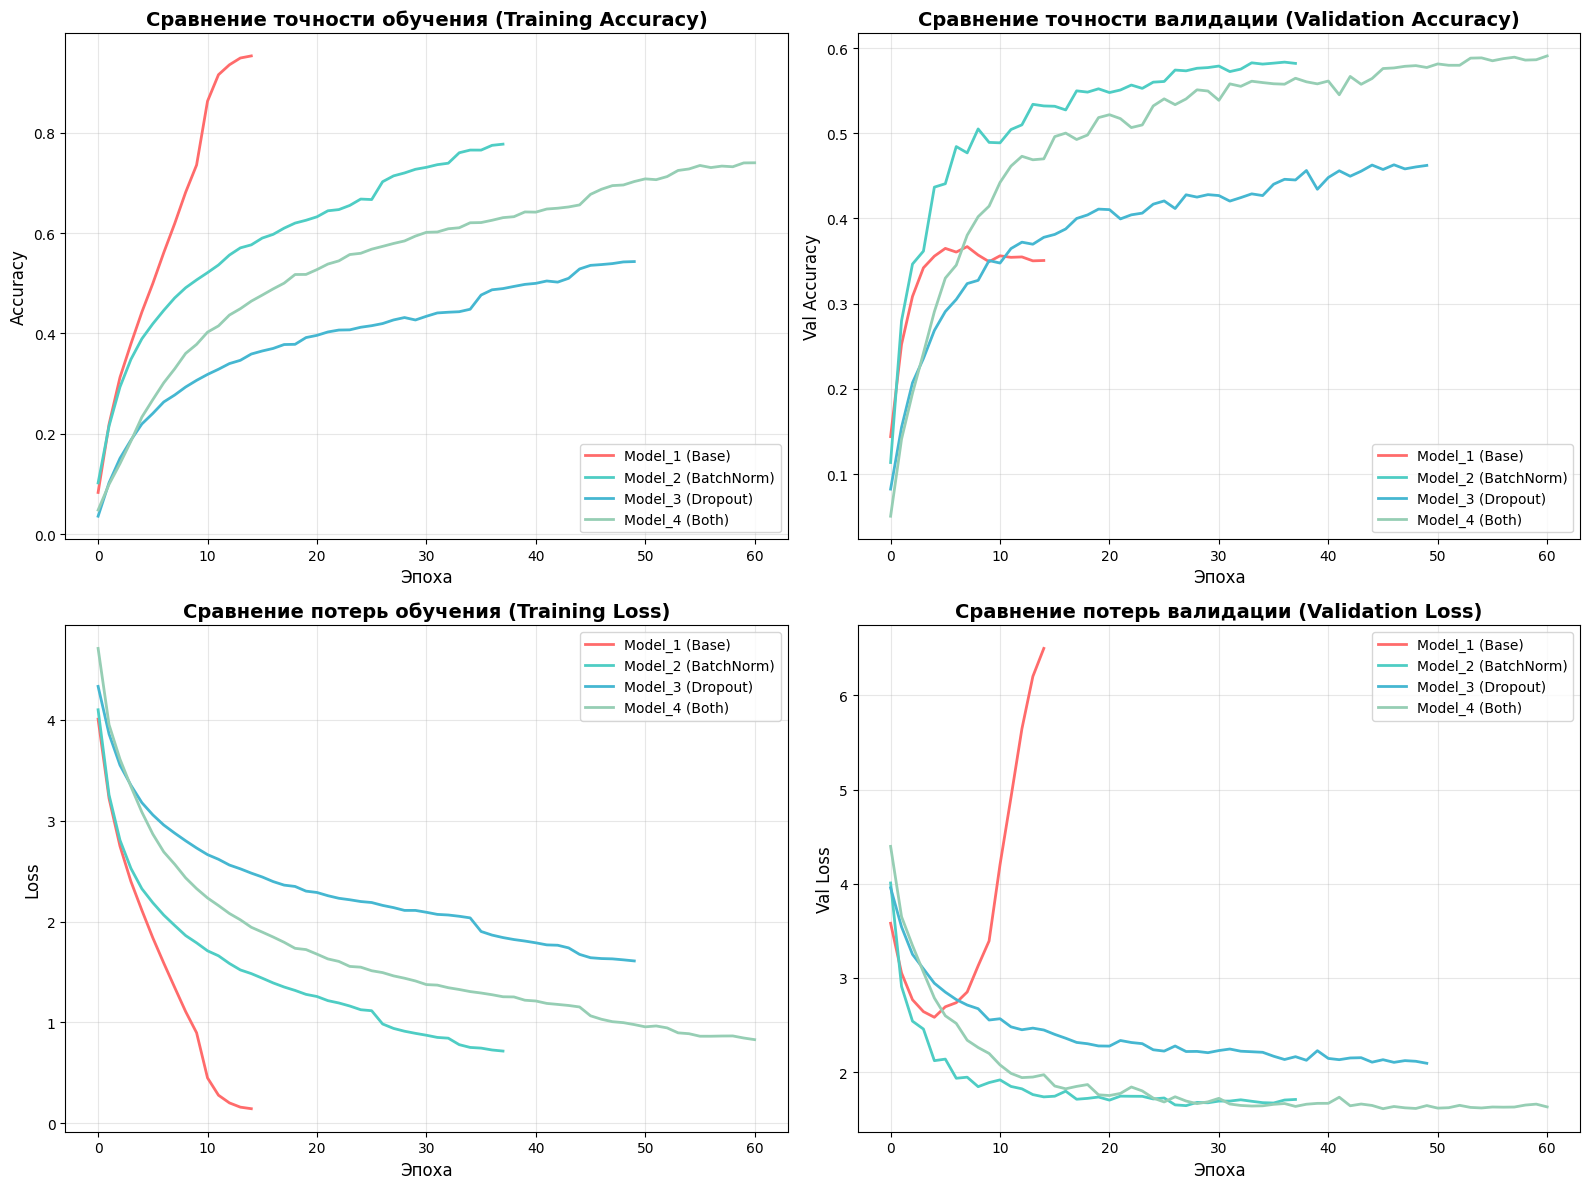

In [ ]:
import pandas as pd

def plot_training_history(histories, model_names):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    axes[0, 0].set_title('Сравнение точности обучения (Training Accuracy)', fontsize=14, fontweight='bold')
    for i, (hist, name) in enumerate(zip(histories, model_names)):
        axes[0, 0].plot(hist.history['accuracy'], label=f'{name}', linewidth=2, color=colors[i])
    axes[0, 0].set_xlabel('Эпоха', fontsize=12)
    axes[0, 0].set_ylabel('Accuracy', fontsize=12)
    axes[0, 0].legend(loc='lower right')
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].set_title('Сравнение точности валидации (Validation Accuracy)', fontsize=14, fontweight='bold')
    for i, (hist, name) in enumerate(zip(histories, model_names)):
        axes[0, 1].plot(hist.history['val_accuracy'], label=f'{name}', linewidth=2, color=colors[i])
    axes[0, 1].set_xlabel('Эпоха', fontsize=12)
    axes[0, 1].set_ylabel('Val Accuracy', fontsize=12)
    axes[0, 1].legend(loc='lower right')
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].set_title('Сравнение потерь обучения (Training Loss)', fontsize=14, fontweight='bold')
    for i, (hist, name) in enumerate(zip(histories, model_names)):
        axes[1, 0].plot(hist.history['loss'], label=f'{name}', linewidth=2, color=colors[i])
    axes[1, 0].set_xlabel('Эпоха', fontsize=12)
    axes[1, 0].set_ylabel('Loss', fontsize=12)
    axes[1, 0].legend(loc='upper right')
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].set_title('Сравнение потерь валидации (Validation Loss)', fontsize=14, fontweight='bold')
    for i, (hist, name) in enumerate(zip(histories, model_names)):
        axes[1, 1].plot(hist.history['val_loss'], label=f'{name}', linewidth=2, color=colors[i])
    axes[1, 1].set_xlabel('Эпоха', fontsize=12)
    axes[1, 1].set_ylabel('Val Loss', fontsize=12)
    axes[1, 1].legend(loc='upper right')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

histories = [history_1, history_2, history_3, history_4]
model_names = ['Model_1 (Base)', 'Model_2 (BatchNorm)', 'Model_3 (Dropout)', 'Model_4 (Both)']

plot_training_history(histories, model_names)

              Model  Test Accuracy  Test Loss  Best Val Accuracy
     Model_1 (Base)         0.3723     2.5301             0.3670
Model_2 (BatchNorm)         0.5839     1.5947             0.5835
  Model_3 (Dropout)         0.4712     2.0695             0.4630
     Model_4 (Both)         0.5739     1.6073             0.5908


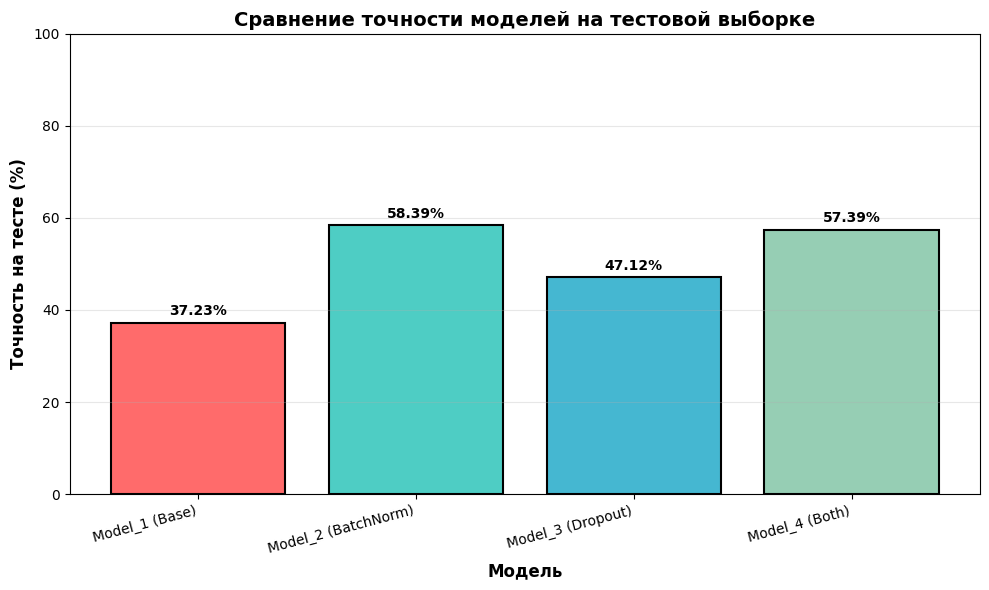

In [ ]:

results = {
    'Model': ['Model_1 (Base)', 'Model_2 (BatchNorm)', 'Model_3 (Dropout)', 'Model_4 (Both)'],
    'Test Accuracy': [test_acc_1, test_acc_2, test_acc_3, test_acc_4],
    'Test Loss': [test_loss_1, test_loss_2, test_loss_3, test_loss_4],
    'Best Val Accuracy': [
        max(history_1.history['val_accuracy']),
        max(history_2.history['val_accuracy']),
        max(history_3.history['val_accuracy']),
        max(history_4.history['val_accuracy'])
    ]
}

df_results = pd.DataFrame(results)
df_results['Test Accuracy'] = df_results['Test Accuracy'].round(4)
df_results['Test Loss'] = df_results['Test Loss'].round(4)
df_results['Best Val Accuracy'] = df_results['Best Val Accuracy'].round(4)

print(df_results.to_string(index=False))
print('=' * 80)

# Столбчатая диаграмма
plt.figure(figsize=(10, 6))
bars = plt.bar(results['Model'], [acc * 100 for acc in results['Test Accuracy']],
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], edgecolor='black', linewidth=1.5)

plt.xlabel('Модель', fontsize=12, fontweight='bold')
plt.ylabel('Точность на тесте (%)', fontsize=12, fontweight='bold')
plt.title('Сравнение точности моделей на тестовой выборке', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 100)

for bar, acc in zip(bars, results['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc*100:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Анализ результатов обучения моделей

Проведенный эксперимент наглядно продемонстрировал критическую важность методов регуляризации при обучении глубоких сверточных сетей на сложном датасете CIFAR-100.

**1. Проблема переобучения в базовой модели (Model_1)**
Самым ярким примером необходимости регуляризации стало поведение первой модели (красная линия на графиках). Как видно из графика **Training Accuracy**, модель очень быстро выучила обучающую выборку (точность стремительно выросла почти до 100%), а **Training Loss** упал до нуля. Однако это привело к катастрофическому переобучению: на графике **Validation Loss** мы видим резкий взлет потерь после 10-й эпохи, а точность на валидации застряла на уровне ~35-40%. В итоге, на тестовой выборке модель показала худший результат (**37.23%**), так как она просто запомнила картинки, но не научилась выделять общие признаки.

**2. Эффективность BatchNormalization (Model_2)**
Модель с использованием пакетной нормализации показала наилучший результат (**58.39%**). Графики подтверждают, что BatchNormalization стабилизировала процесс обучения:
*   Кривые потерь (Loss) снижаются плавно и уверенно без резких скачков.
*   Разрыв между точностью на обучении и валидации минимален, что говорит о хорошем обобщении.
*   Обучение сходится быстрее, чем у моделей с Dropout, позволяя достичь высокой точности за меньшее количество эпох.

**3. Роль Dropout и комбинированный подход (Model_3 и Model_4)**
*   **Model_3 (только Dropout):** Показала результат лучше базовой (**47.12%**), но уступила моделям с нормализацией. Dropout эффективно боролся с переобучением (нет всплеска Val Loss), но значительно замедлил сходимость модели (синяя линия на графиках растет медленнее всех).
*   **Model_4 (BatchNorm + Dropout):** Показала отличный результат (**57.39%**), практически идентичный лучшей модели. Это подтверждает, что комбинация методов работает надежно. Небольшое отставание от Model_2 может быть связано с тем, что для данной архитектуры и количества эпох BatchNormalization оказалось достаточно мощным регуляризатором, а дополнительный Dropout лишь незначительно усложнил обучение.

### Итоговый вывод

На основании полученных данных можно сделать следующие заключения:

1.  **Обучение без регуляризации на CIFAR-100 невозможно.** Базовая модель деградировала из-за переобучения, несмотря на высокую точность на тренировочных данных.
2.  **BatchNormalization является наиболее эффективным инструментом** в данном эксперименте. Она не только предотвратила переобучение, но и ускорила сходимость, позволив модели достичь максимальной тестовой точности (~58%).
3.  **Комбинация методов (Model_4) является самым надежным решением.** Хотя в данном конкретном запуске Model_2 выиграла с минимальным отрывом, использование связки `BatchNorm + Dropout` гарантирует стабильность и защищает от переобучения в долгосрочной перспективе, делая модель более робастной (менее чувствительной к выбросам и шуму).


### **1.9. Визуализируйте карты активации модели с BatchNorm() и Dropout(),отдельно по 5 классам (на Ваш выбор):**

Найдено Conv2D слоёв: 7
Добавлен выход слоя: conv2d_18 ((None, 32, 32, 32))
Добавлен выход слоя: conv2d_19 ((None, 32, 32, 32))
Добавлен выход слоя: conv2d_20 ((None, 16, 16, 64))
Добавлен выход слоя: conv2d_21 ((None, 16, 16, 64))
Добавлен выход слоя: conv2d_22 ((None, 8, 8, 128))
Добавлен выход слоя: conv2d_23 ((None, 8, 8, 128))
Добавлен выход слоя: conv2d_24 ((None, 4, 4, 256))
Количество выходов: 7

Выбранные классы: ['apple', 'bowl', 'couch', 'mouse', 'skunk']


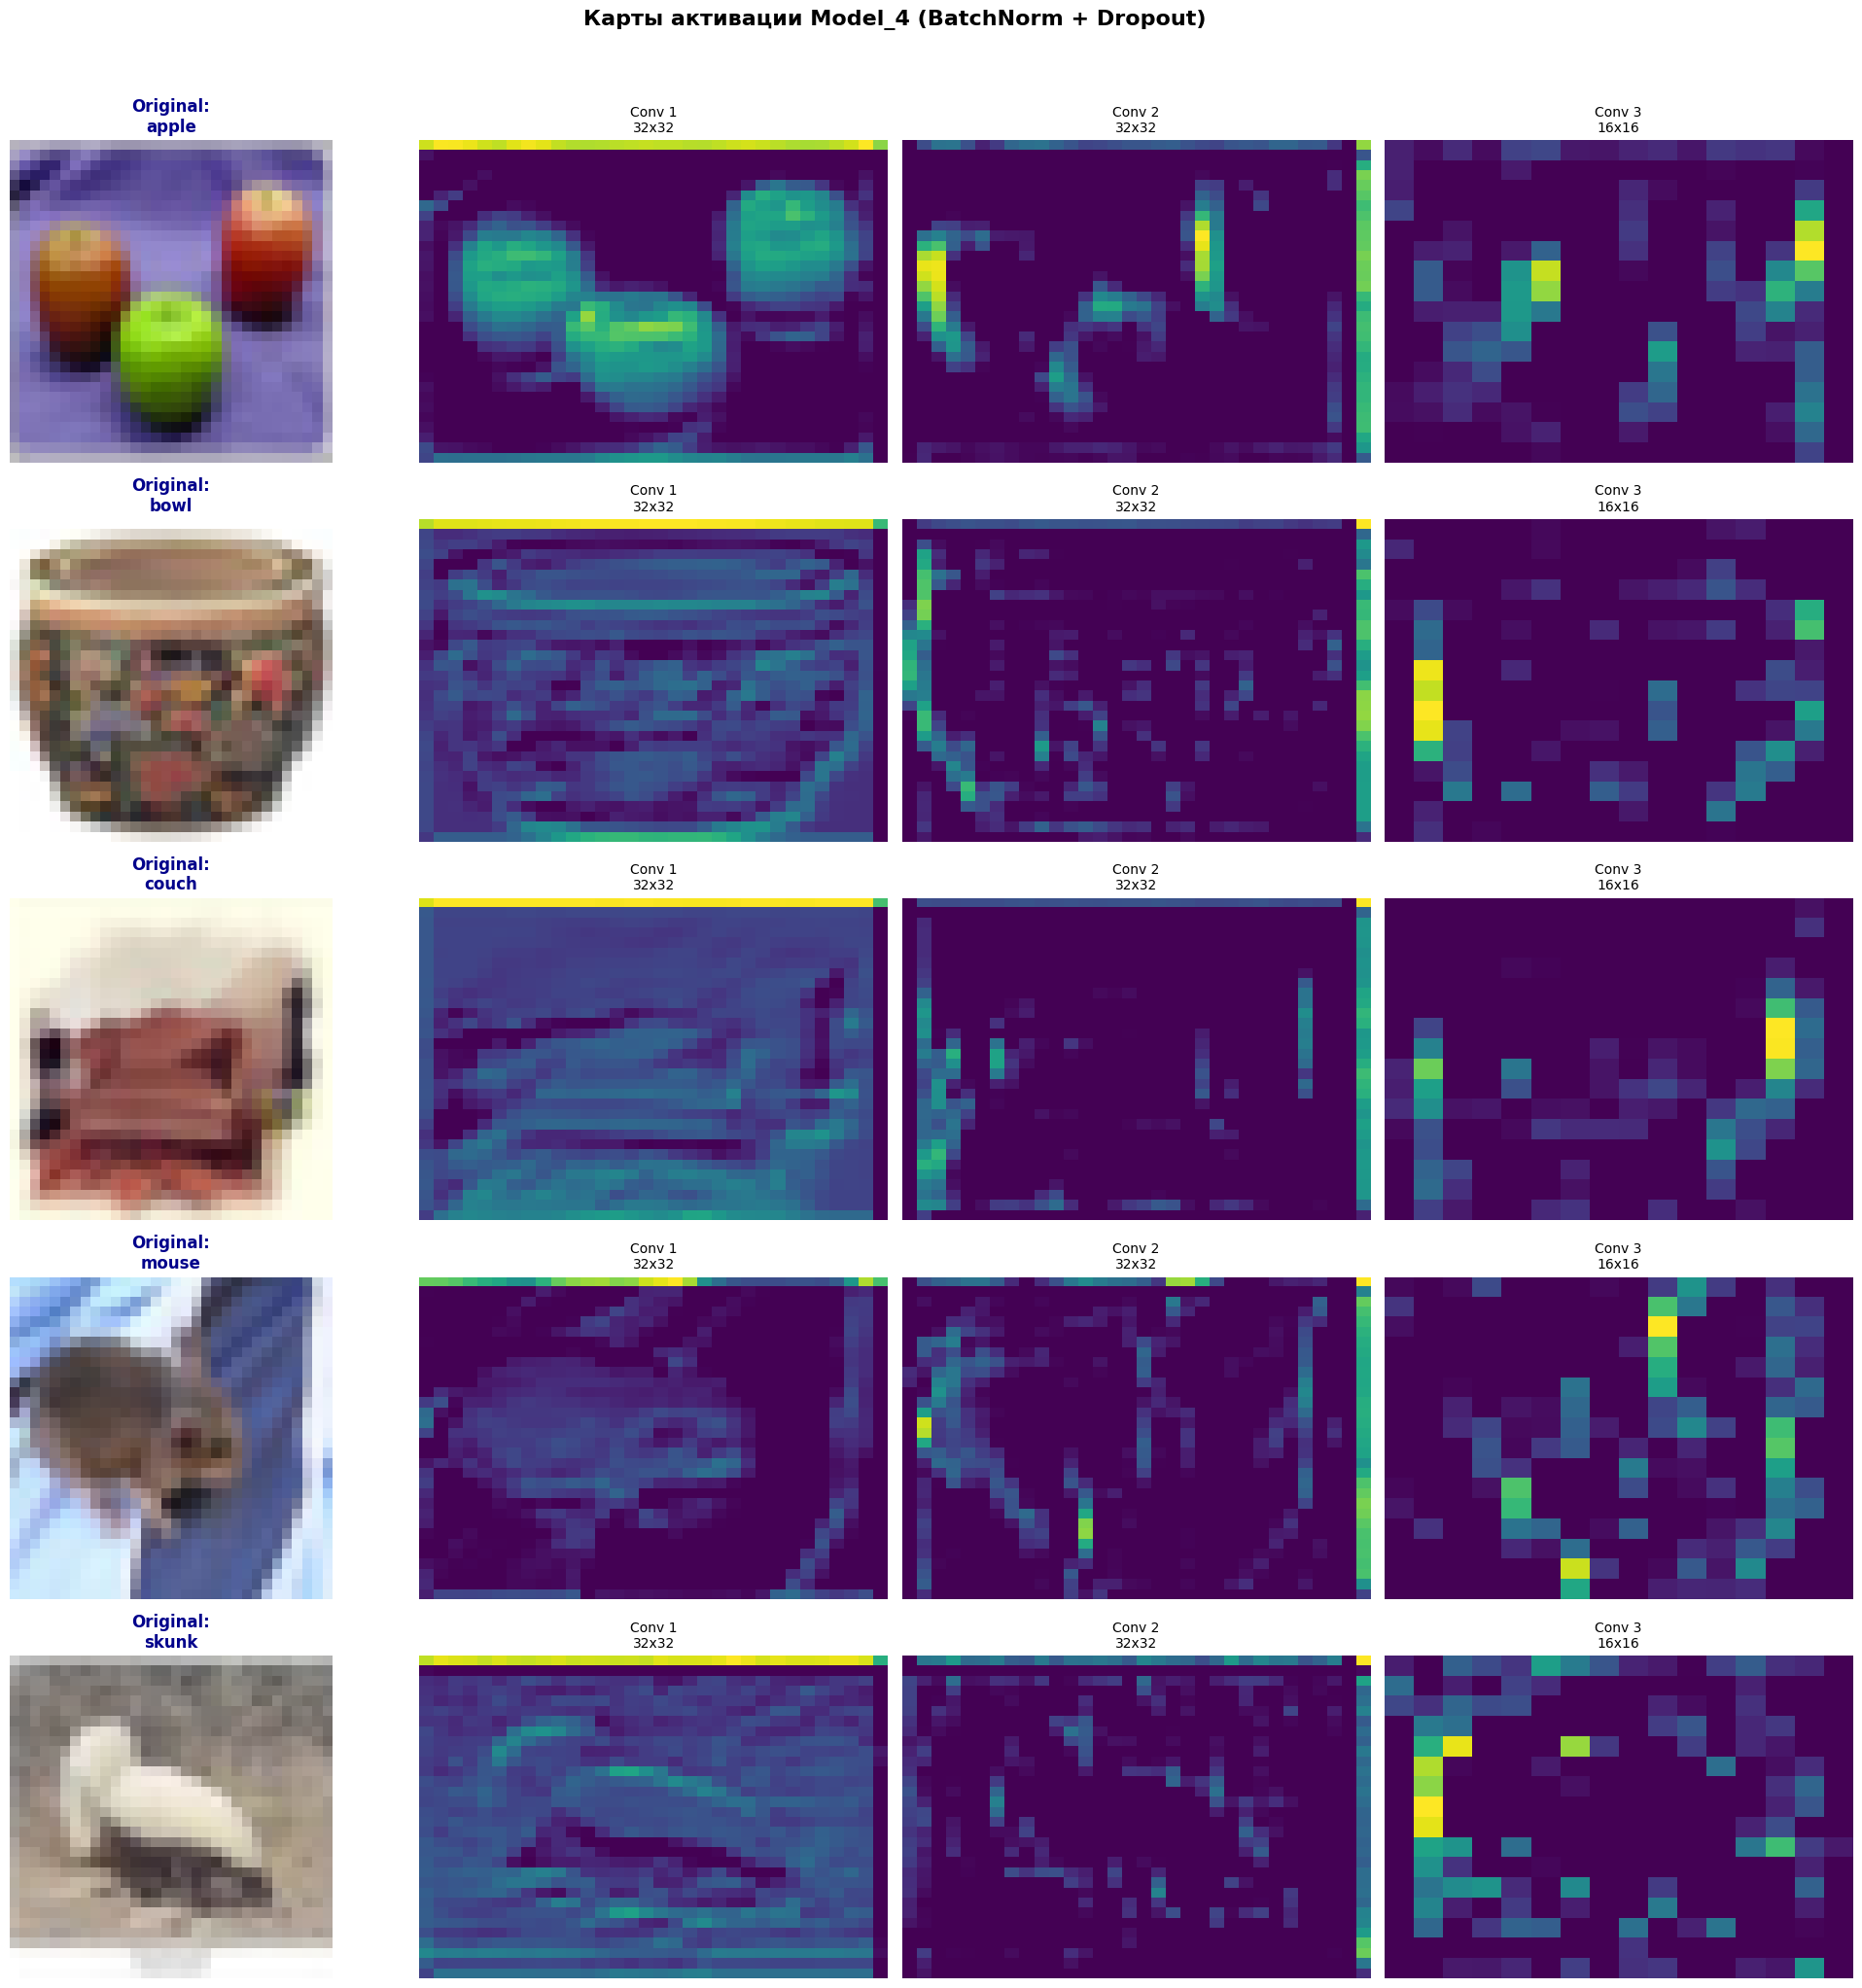

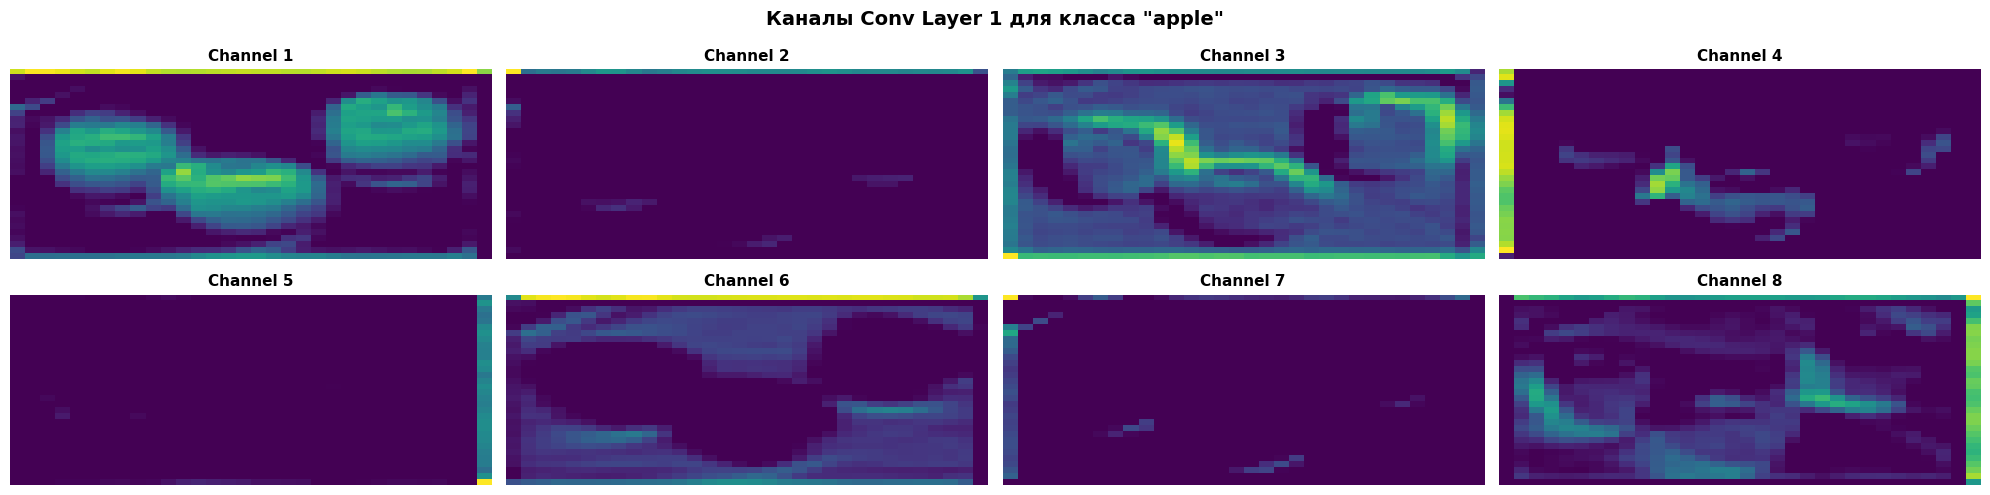

In [ ]:
from keras.models import Model
from keras.layers import Input

# Находим все Conv2D слои
conv_layers = [layer for layer in model_4.layers if isinstance(layer, Conv2D)]
print(f'Найдено Conv2D слоёв: {len(conv_layers)}')

if len(conv_layers) > 0:
    input_layer = Input(shape=(32, 32, 3))

    # Проходим по всем слоям модели и собираем выходы Conv2D
    x = input_layer
    conv_outputs = []

    for layer in model_4.layers:
        try:
            x = layer(x)
            # Если это Conv2D слой - сохраняем выход
            if isinstance(layer, Conv2D):
                conv_outputs.append(x)
                print(f'Добавлен выход слоя: {layer.name} ({x.shape})')
        except Exception as e:
            print(f'Пропущен слой {layer.name}: {e}')

    activation_model = Model(inputs=input_layer, outputs=conv_outputs)
    print(f'Количество выходов: {len(conv_outputs)}')

    selected_classes = [0, 10, 25, 50, 75]
    class_names_selected = [label_names[i] for i in selected_classes]

    print(f'\nВыбранные классы: {class_names_selected}')

    sample_images = []
    sample_labels = []

    for class_idx in selected_classes:
        indices = np.where(testy == class_idx)[0]
        if len(indices) > 0:
            sample_idx = indices[0]
            sample_images.append(testX_norm[sample_idx:sample_idx+1])
            sample_labels.append(class_idx)

    n_samples = len(sample_images)
    n_conv_to_show = min(3, len(conv_outputs))  # Показываем первые 3 Conv слоя

    fig, axes = plt.subplots(n_samples, n_conv_to_show + 1, figsize=(20, 4 * n_samples))

    if n_samples == 1:
        axes = axes.reshape(1, -1)

    for i, (img, label_idx) in enumerate(zip(sample_images, sample_labels)):
        # Получаем активации
        activations = activation_model.predict(img, verbose=0)

        # Оригинальное изображение
        axes[i, 0].imshow(img[0])
        axes[i, 0].set_title(f'Original:\n{label_names[label_idx]}',
                            fontsize=12, fontweight='bold', color='darkblue')
        axes[i, 0].axis('off')

        # Карты активации
        for j in range(n_conv_to_show):
            activation_single = activations[j][0, :, :, 0]

            axes[i, j+1].imshow(activation_single, cmap='viridis', aspect='auto')
            axes[i, j+1].set_title(f'Conv {j+1}\n{activations[j].shape[1]}x{activations[j].shape[2]}',
                                  fontsize=10)
            axes[i, j+1].axis('off')

    plt.suptitle('Карты активации Model_4 (BatchNorm + Dropout)',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    demo_img = sample_images[0]
    demo_label = sample_labels[0]

    activations = activation_model.predict(demo_img, verbose=0)

    # Показываем 8 каналов первого Conv слоя
    n_channels = 8
    first_layer_act = activations[0][0, :, :, :n_channels]

    fig, axes = plt.subplots(2, 4, figsize=(20, 5))
    axes = axes.flatten()

    for channel in range(n_channels):
        axes[channel].imshow(first_layer_act[:, :, channel], cmap='viridis', aspect='auto')
        axes[channel].set_title(f'Channel {channel + 1}', fontsize=11, fontweight='bold')
        axes[channel].axis('off')

    plt.suptitle(f'Каналы Conv Layer 1 для класса "{label_names[demo_label]}"',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    print('Conv2D слои не найдены')

## **Задание 2. Загрузите Ваш датасет из предыдущей работы. Разделите его на обучающую и тестовую выборки. Обучите модель классификации с применением BatchNorm() и Dropout(). Сравните точность с моделями, обученными Вами ранее. Визуализируйте карты активаций.**

In [ ]:
# Ваш код #